Analisi delle violazioni SLA sul dataset worst-case dei datapacket.

Ogni osservazione rappresenta il datapacket con Total Delay massimo all’interno di una specifica combinazione Distribution-Scenario-App_ms-Run.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from analysis.utils.analysis_utils import build_sla_summary

df = pd.read_pickle("processed_data/dataset_worst_case_scenarios.pkl")
df.head()

,Distribution,Scenario,App_ms,Run,User,Application,Total Delay,Delay SLAs,SLA_Violation,SLA_Margin,SLA_Margin_Perc,Violation_Amount,Processing Delay,Propagation Delay
0,normal_wide_trunc,2_26_solution_v2,2SSM,run_392,1,1,58,63.924,False,-5.924,-9.267,0.0,33,25
1,normal_wide_trunc,2_26_solution_v2,2SSM,run_619,2,2,49,63.924,False,-14.924,-23.346,0.0,23,26
2,normal_wide_trunc,2_26_solution_v2,2SSM,run_976,2,2,53,63.924,False,-10.924,-17.089,0.0,27,26
3,normal_wide_trunc,2_26_solution_v2,2SSM,run_338,1,1,56,63.924,False,-7.924,-12.396,0.0,31,25
4,normal_wide_trunc,2_26_solution_v2,2SSM,run_235,1,1,55,63.924,False,-8.924,-13.960,0.0,30,25


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 336000 entries, 0 to 335999
Data columns (total 14 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Distribution       336000 non-null  object 
 1   Scenario           336000 non-null  object 
 2   App_ms             336000 non-null  object 
 3   Run                336000 non-null  object 
 4   User               336000 non-null  int64  
 5   Application        336000 non-null  int64  
 6   Total Delay        336000 non-null  int64  
 7   Delay SLAs         336000 non-null  float64
 8   SLA_Violation      336000 non-null  bool   
 9   SLA_Margin         336000 non-null  float64
 10  SLA_Margin_Perc    336000 non-null  float64
 11  Violation_Amount   336000 non-null  float64
 12  Processing Delay   336000 non-null  int64  
 13  Propagation Delay  336000 non-null  int64  
dtypes: bool(1), float64(4), int64(5), object(4)
memory usage: 33.6+ MB


In [3]:
print("SLA violation", df['SLA_Violation'].sum(), "out of", len(df))
print(f"SLA violation rate: {df['SLA_Violation'].mean() * 100:.2f}%")


SLA violation 34924 out of 336000
SLA violation rate: 10.39%


* **`Distribution`**: la distribuzione statistica usata nella simulazione per generare i tempi/valori variabili del modello.

* **`Runs`**: il numero totale di run considerate per quella distribuzione.

* **`Violations`**: il numero di run in cui il worst-case datapacket ha superato la soglia SLA.

* **`Violation_Rate`**: la percentuale di run in violazione rispetto al totale delle run della distribuzione.

* **`Mean_Total_Delay`**: la media del `Total Delay` del worst-case datapacket sulle run della distribuzione.

* **`Median_Total_Delay`**: la mediana del `Total Delay` del worst-case datapacket; rappresenta il valore centrale ed è meno sensibile agli outlier rispetto alla media.

* **`Max_Total_Delay`**: il massimo `Total Delay` osservato tra tutte le run della distribuzione, cioè il caso peggiore assoluto.

* **`Mean_SLA_Margin`**: la media della differenza tra `Total Delay` e `Delay SLA` su tutte le run.
  Valori:

  * negativi → in media sotto soglia
  * positivi → in media sopra soglia

* **`Median_SLA_Margin`**: la mediana del margine rispetto alla SLA. Anche qui:

  * negativo = caso tipico sotto soglia
  * positivo = caso tipico sopra soglia

* **`Min_SLA_Margin`**: il valore minimo del margine rispetto alla SLA, cioè il caso più distante sotto soglia osservato.

* **`Max_SLA_Margin`**: il valore massimo del margine rispetto alla SLA, cioè il massimo superamento della soglia osservato. Se è negativo, significa che non ci sono state violazioni.

* **`Mean_Violation_Amount`**: la media della violazione effettiva su tutte le run, dove le run senza violazione valgono 0.
  Misura quindi la severità media “complessiva” delle violazioni.

* **`Max_Violation_Amount`**: la massima violazione osservata, cioè di quanto la SLA è stata superata nel caso peggiore.

* **`Mean_Safe_Margin`**: la media del margine rispetto alla SLA considerando solo le run **senza violazione**. È quindi un indicatore del margine di sicurezza medio.

* **`Median_Safe_Margin`**: la mediana del margine rispetto alla SLA considerando solo le run senza violazione.

* **`Max_Safe_Margin`**: il margine più alto tra quelli che non superano la soglia, cioè il caso **più vicino al limite SLA senza violarlo**. È tipicamente un valore negativo molto vicino a zero.

* **`Mean_Violating_Margin`**: la media del margine rispetto alla SLA considerando solo le run **in violazione**. Indica di quanto, in media, la soglia viene superata quando la violazione avviene.

* **`Median_Violating_Margin`**: la mediana del margine rispetto alla SLA considerando solo le run in violazione. Utile per descrivere la gravità “tipica” delle violazioni riducendo l’effetto degli outlier.


In [4]:
dist_summary = build_sla_summary(df, 'Distribution')
dist_summary

,Distribution,Runs,Violations,Violation_Rate,Mean_Total_Delay,Median_Total_Delay,Max_Total_Delay,Mean_SLA_Margin,Median_SLA_Margin,Min_SLA_Margin,Max_SLA_Margin,Mean_Violation_Amount,Max_Violation_Amount,Mean_Safe_Margin,Median_Safe_Margin,Max_Safe_Margin,Mean_Violating_Margin,Median_Violating_Margin
0,deterministic,48000,0,0.000,60.438,58.5,81,-9.696,-7.891,-26.112,-0.234,0.000,0.000,-9.696,-7.891,-0.234,NaN,NaN
1,exponential,48000,10083,21.006,60.091,58.0,161,-10.043,-11.864,-49.112,97.076,2.287,97.076,-15.608,-14.924,-0.112,10.885,7.766
2,gamma_k2,48000,7051,14.690,59.277,58.0,134,-10.857,-11.273,-49.112,57.888,1.041,57.888,-13.946,-13.228,-0.112,7.085,5.076
3,normal,48000,48,0.100,58.371,56.0,83,-11.763,-10.112,-32.112,1.766,0.001,1.766,-11.776,-10.112,-0.234,0.808,0.766
4,normal_wide,48000,4894,10.196,60.130,59.0,100,-10.004,-9.427,-46.112,21.766,0.369,21.766,-11.551,-10.427,-0.112,3.618,2.766
5,normal_wide_trunc,48000,11925,24.844,65.144,63.0,103,-4.990,-4.273,-33.112,23.766,0.990,23.766,-7.957,-6.486,-0.112,3.986,3.082
6,uniform,48000,923,1.923,58.553,57.0,90,-11.581,-10.552,-40.112,7.766,0.037,7.766,-11.845,-10.864,-0.112,1.921,1.727


La distribuzione esponenziale risulta la più critica rispetto al rispetto della SLA. Pur mostrando valori medi e mediani del worst-case delay comparabili con quelli delle altre distribuzioni, presenta una percentuale di violazione nettamente superiore (10.21%) e il massimo ritardo osservato più elevato (105). Questo suggerisce che la differenza principale non risiede nel comportamento medio, ma nella maggiore presenza di casi estremi.
La distribuzione gaussiana risulta invece la più robusta, non mostrando alcuna violazione SLA nelle 480 run analizzate. La distribuzione uniforme assume un comportamento intermedio, con un numero limitato di violazioni e una severità contenuta.

In [5]:
app_summary = build_sla_summary(df, 'App_ms')
app_summary

,App_ms,Runs,Violations,Violation_Rate,Mean_Total_Delay,Median_Total_Delay,Max_Total_Delay,Mean_SLA_Margin,Median_SLA_Margin,Min_SLA_Margin,Max_SLA_Margin,Mean_Violation_Amount,Max_Violation_Amount,Mean_Safe_Margin,Median_Safe_Margin,Max_Safe_Margin,Mean_Violating_Margin,Median_Violating_Margin
0,1MMM,21000,2384,11.352,50.972,52.0,140,-12.568,-9.234,-49.112,78.766,0.833,78.766,-15.117,-11.273,-0.112,7.341,4.766
1,1MMS,21000,3545,16.881,58.366,57.0,142,-5.174,-5.273,-28.273,72.888,1.142,72.888,-7.599,-6.234,-0.112,6.764,4.727
2,1MSM,7000,95,1.357,50.894,51.0,102,-18.218,-18.112,-36.112,32.888,0.109,32.888,-18.579,-18.112,-0.112,8.046,6.888
3,1MSS,7000,158,2.257,54.535,55.0,118,-14.577,-14.112,-33.112,48.888,0.194,48.888,-15.112,-15.112,-0.112,8.597,5.888
4,1SMM,42000,5579,13.283,57.223,57.0,157,-9.092,-8.112,-44.864,95.766,0.916,95.766,-11.541,-9.486,-0.112,6.896,4.766
5,1SMS,42000,5676,13.514,57.302,57.0,142,-9.012,-7.918,-43.864,80.766,0.888,80.766,-11.447,-9.486,-0.112,6.570,4.514
6,1SSM,42000,4840,11.524,59.383,58.0,147,-6.932,-7.486,-28.273,66.136,0.682,66.136,-8.606,-8.112,-0.112,5.920,3.766
7,1SSS,42000,5008,11.924,59.966,58.0,118,-6.349,-6.864,-27.273,55.082,0.616,55.082,-7.907,-7.486,-0.112,5.163,3.514
8,2MMM,7000,208,2.971,68.429,67.0,130,-18.123,-19.552,-42.552,43.448,0.258,43.448,-18.943,-19.552,-0.552,8.669,5.448
9,2MMS,7000,215,3.071,69.039,68.0,147,-17.513,-18.552,-41.552,60.448,0.291,60.448,-18.368,-18.552,-0.552,9.462,6.448


Le applicazioni della famiglia 2 tendono ad avere, in media, Total Delay più alto rispetto a molte della famiglia 1.

Ci sono profili con delay medio alto ma senza violazioni, e profili con delay medio non necessariamente massimo ma con più violazioni. Per esempio:

- 2MMS ha delay medio molto alto, ma Violation_Rate = 0
- 2SMS ha delay medio simile, ma Violation_Rate = 10%

Il rispetto della SLA dipende non solo dal livello medio del worst-case delay, ma anche dalla variabilità e dalla vicinanza del ritardo osservato alla soglia prevista per quello specifico profilo applicativo.

Quindi, anche se 2SMS è il peggiore per frequenza di violazione, 2SSM è il più severo in termini di singola violazione massima.

Famiglia 1*

I profili 1* mostrano comportamento abbastanza eterogeneo:

alcuni non violano mai
altri, come 1SSS, 1SMM e 1MMM, mostrano violazioni non trascurabili
Famiglia 2*

I profili 2* tendono ad avere delay medi più alti, ma non tutti risultano critici per SLA:

2SMS è chiaramente il più problematico
2SMM e 2SSM mostrano anch’essi criticità
2MMM, 2MMS, 2MSM restano invece sempre entro soglia

Quindi all’interno della famiglia 2* non c’è un comportamento uniforme: alcuni profili sono robusti, altri molto più sensibili.

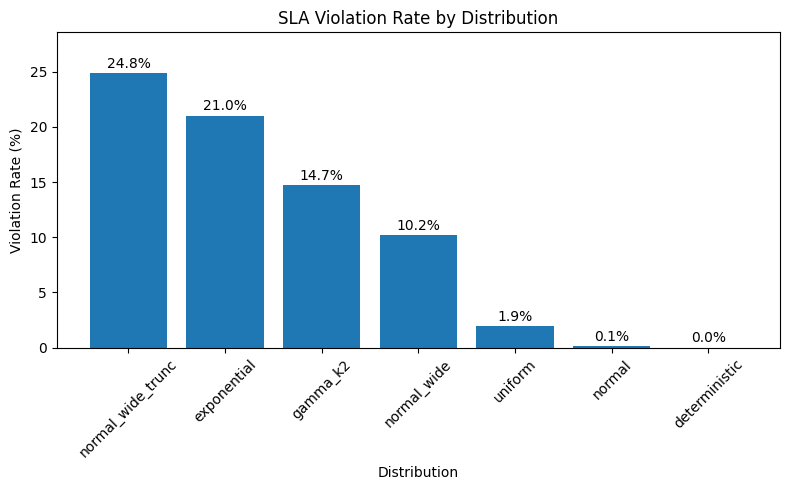

In [6]:
plot_df = dist_summary.sort_values('Violation_Rate', ascending=False)

plt.figure(figsize=(8, 5))
plt.bar(plot_df['Distribution'], plot_df['Violation_Rate'])
plt.title('SLA Violation Rate by Distribution')
plt.xlabel('Distribution')
plt.xticks(rotation=45)
plt.ylabel('Violation Rate (%)')
plt.ylim(0, max(plot_df['Violation_Rate'].max() * 1.15, 5))

for i, v in enumerate(plot_df['Violation_Rate']):
    plt.text(i, v + 0.5, f"{v:.1f}%", ha='center')

plt.tight_layout()
plt.show()

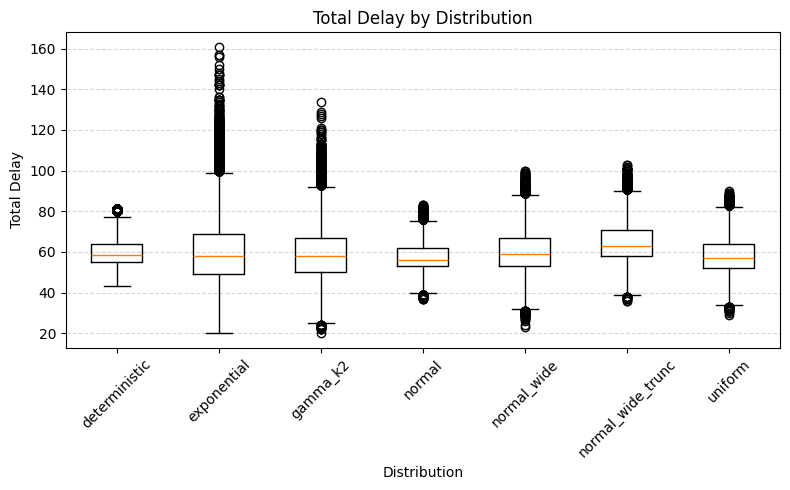

In [7]:
categories = sorted(df['Distribution'].dropna().unique())
data = [df.loc[df['Distribution'] == c, 'Total Delay'].dropna() for c in categories]

plt.figure(figsize=(8, 5))
plt.boxplot(data, tick_labels=categories)
plt.title('Total Delay by Distribution')
plt.xlabel('Distribution')
plt.ylabel('Total Delay')

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

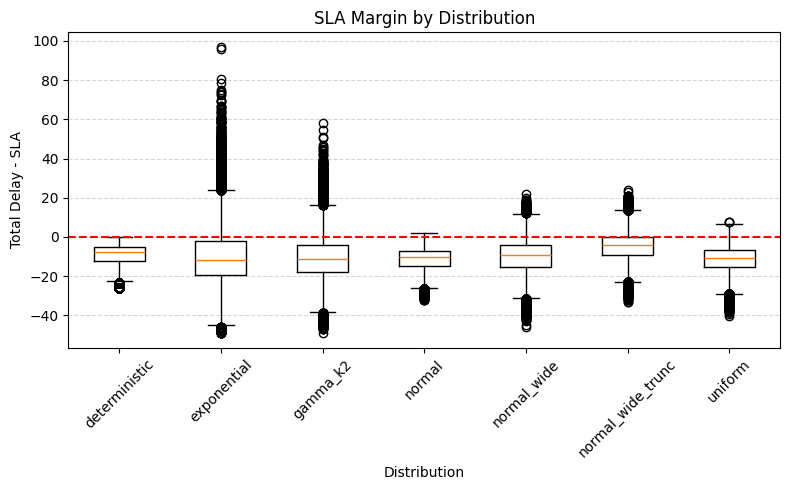

In [8]:
categories = sorted(df['Distribution'].dropna().unique())
data = [df.loc[df['Distribution'] == c, 'SLA_Margin'].dropna() for c in categories]

plt.figure(figsize=(8, 5))
plt.boxplot(data, tick_labels=categories)
plt.title('SLA Margin by Distribution')
plt.xlabel('Distribution')
plt.ylabel('Total Delay - SLA')

plt.axhline(0, linestyle='--', color='red')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

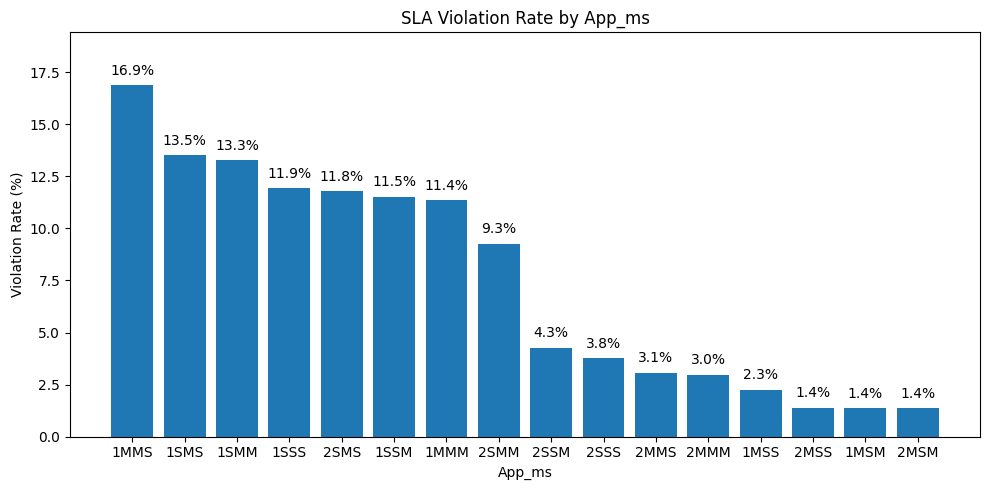

In [9]:
plot_df = app_summary.sort_values('Violation_Rate', ascending=False)

plt.figure(figsize=(10, 5))
plt.bar(plot_df['App_ms'], plot_df['Violation_Rate'])
plt.title('SLA Violation Rate by App_ms')
plt.xlabel('App_ms')
plt.ylabel('Violation Rate (%)')
plt.ylim(0, max(plot_df['Violation_Rate'].max() * 1.15, 5))

for i, v in enumerate(plot_df['Violation_Rate']):
    plt.text(i, v + 0.5, f"{v:.1f}%", ha='center')

plt.tight_layout()
plt.show()

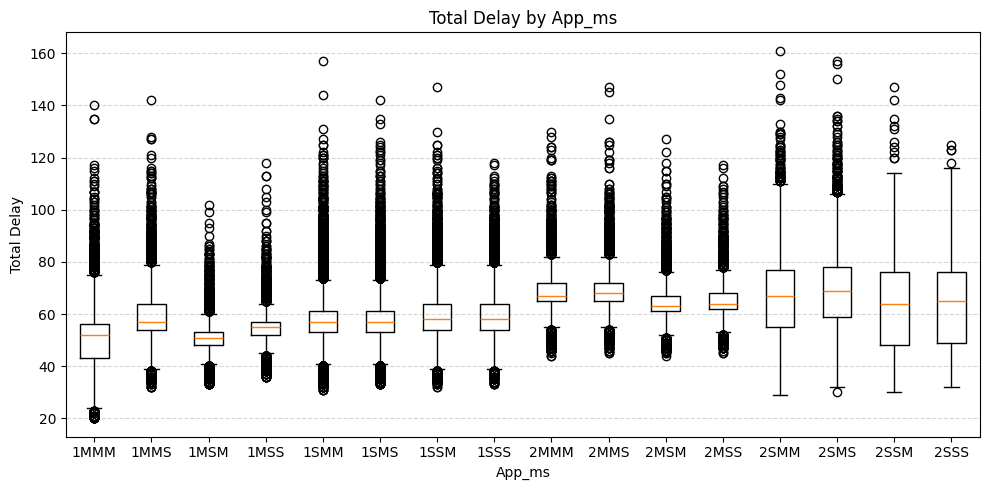

In [10]:
categories = sorted(df['App_ms'].dropna().unique())
data = [df.loc[df['App_ms'] == c, 'Total Delay'].dropna() for c in categories]

plt.figure(figsize=(10, 5))
plt.boxplot(data, tick_labels=categories)
plt.title('Total Delay by App_ms')
plt.xlabel('App_ms')
plt.ylabel('Total Delay')

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

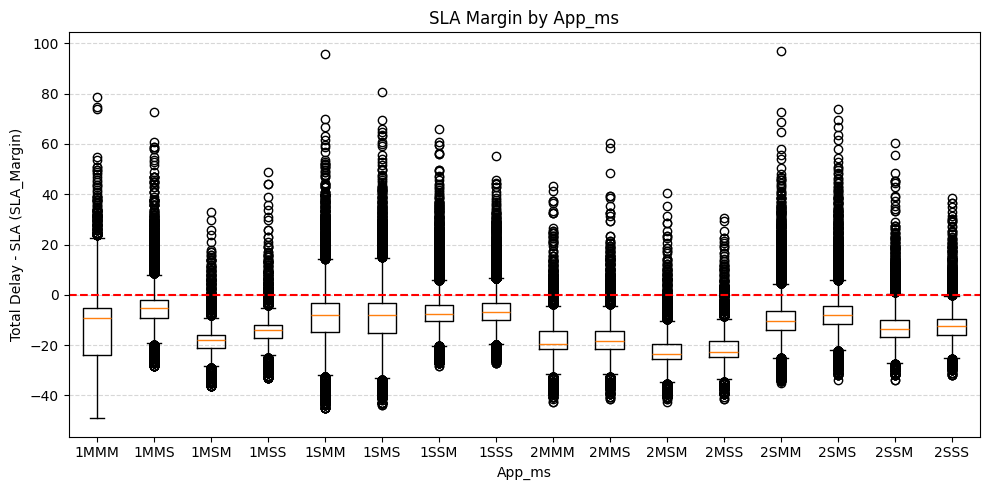

In [11]:
categories = sorted(df['App_ms'].dropna().unique())
data = [df.loc[df['App_ms'] == c, 'SLA_Margin'].dropna() for c in categories]

plt.figure(figsize=(10, 5))
plt.boxplot(data, tick_labels=categories)
plt.title('SLA Margin by App_ms')
plt.xlabel('App_ms')
plt.ylabel('Total Delay - SLA (SLA_Margin)')

plt.axhline(0, linestyle='--', color='red')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

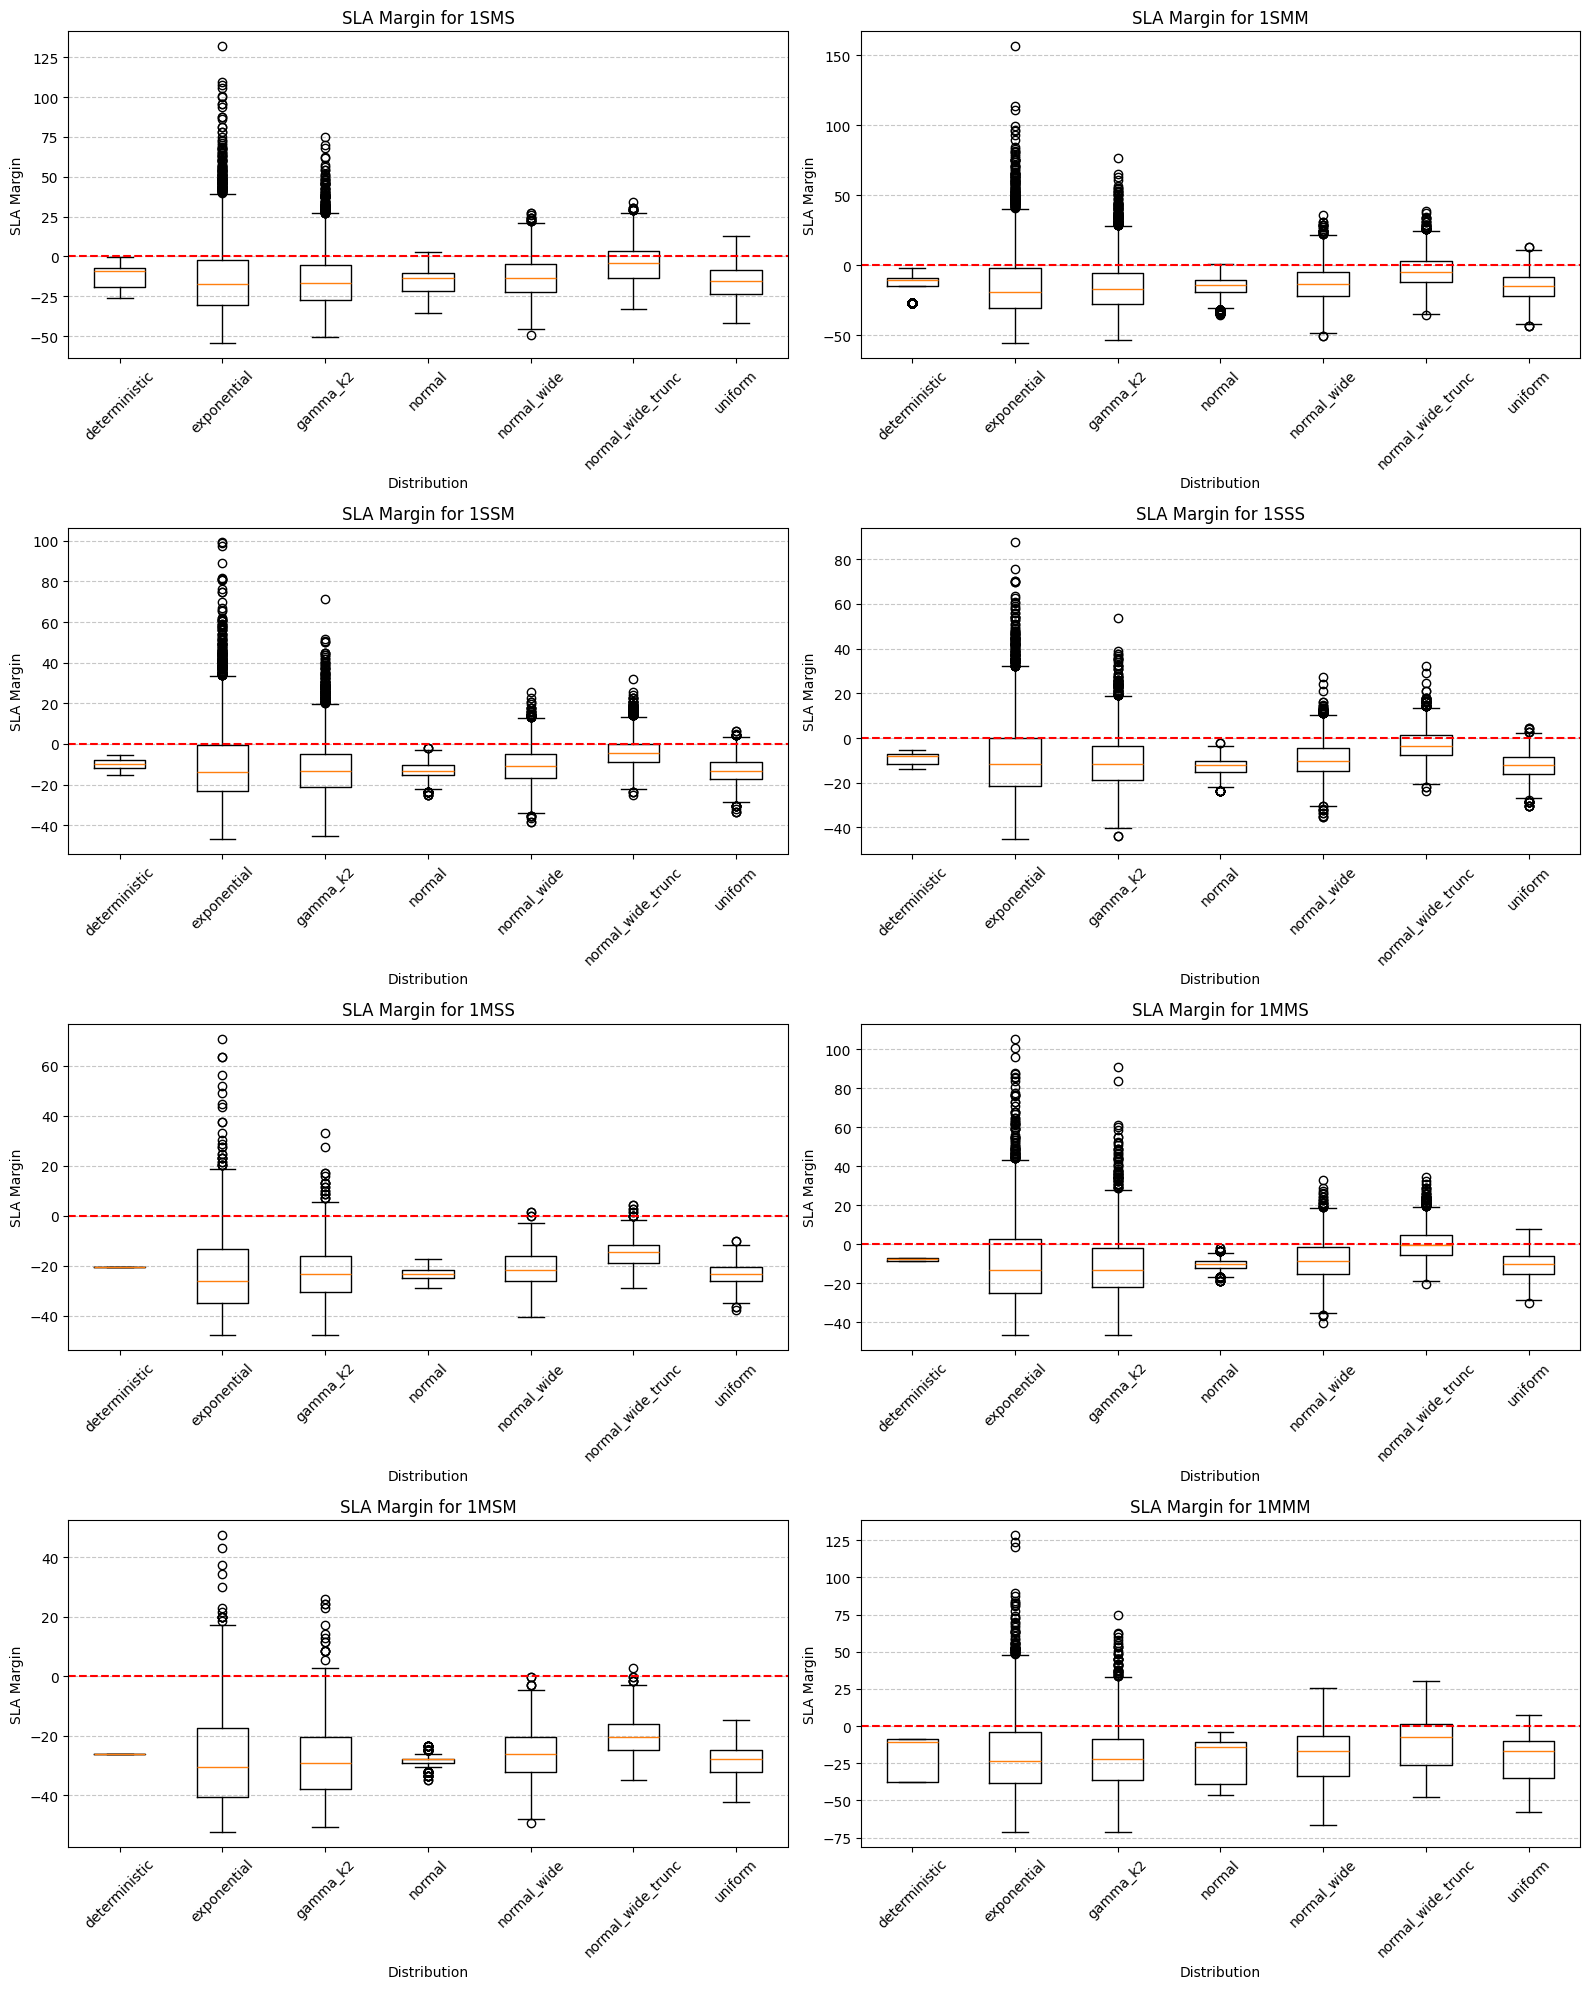

In [12]:
apps_to_plot = df['App_ms'].dropna().unique()
apps_starting_with_1 = [app for app in apps_to_plot if str(app).startswith('1')]

num_apps = len(apps_starting_with_1)

ncols = 2
nrows = (num_apps + 1) // 2

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(16, nrows * 5))
axes = axes.flatten()

categories = sorted(df['Distribution'].dropna().unique())

for i, app in enumerate(apps_starting_with_1):
    ax = axes[i]
    df_app = df[df['App_ms'] == app]

    data = []
    labels = []

    for category in categories:
        subset  = df_app.loc[df_app['Distribution'] == category, 'SLA_Margin_Perc'].dropna()
        if len(subset) > 0:
            data.append(subset)
            labels.append(category)

    ax.boxplot(data, tick_labels=labels)
    ax.axhline(0, linestyle='--', color='red')
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    ax.set_title(f'SLA Margin for {app}')
    ax.set_xlabel('Distribution')
    ax.set_ylabel('SLA Margin')
    ax.tick_params(axis='x', rotation=45)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

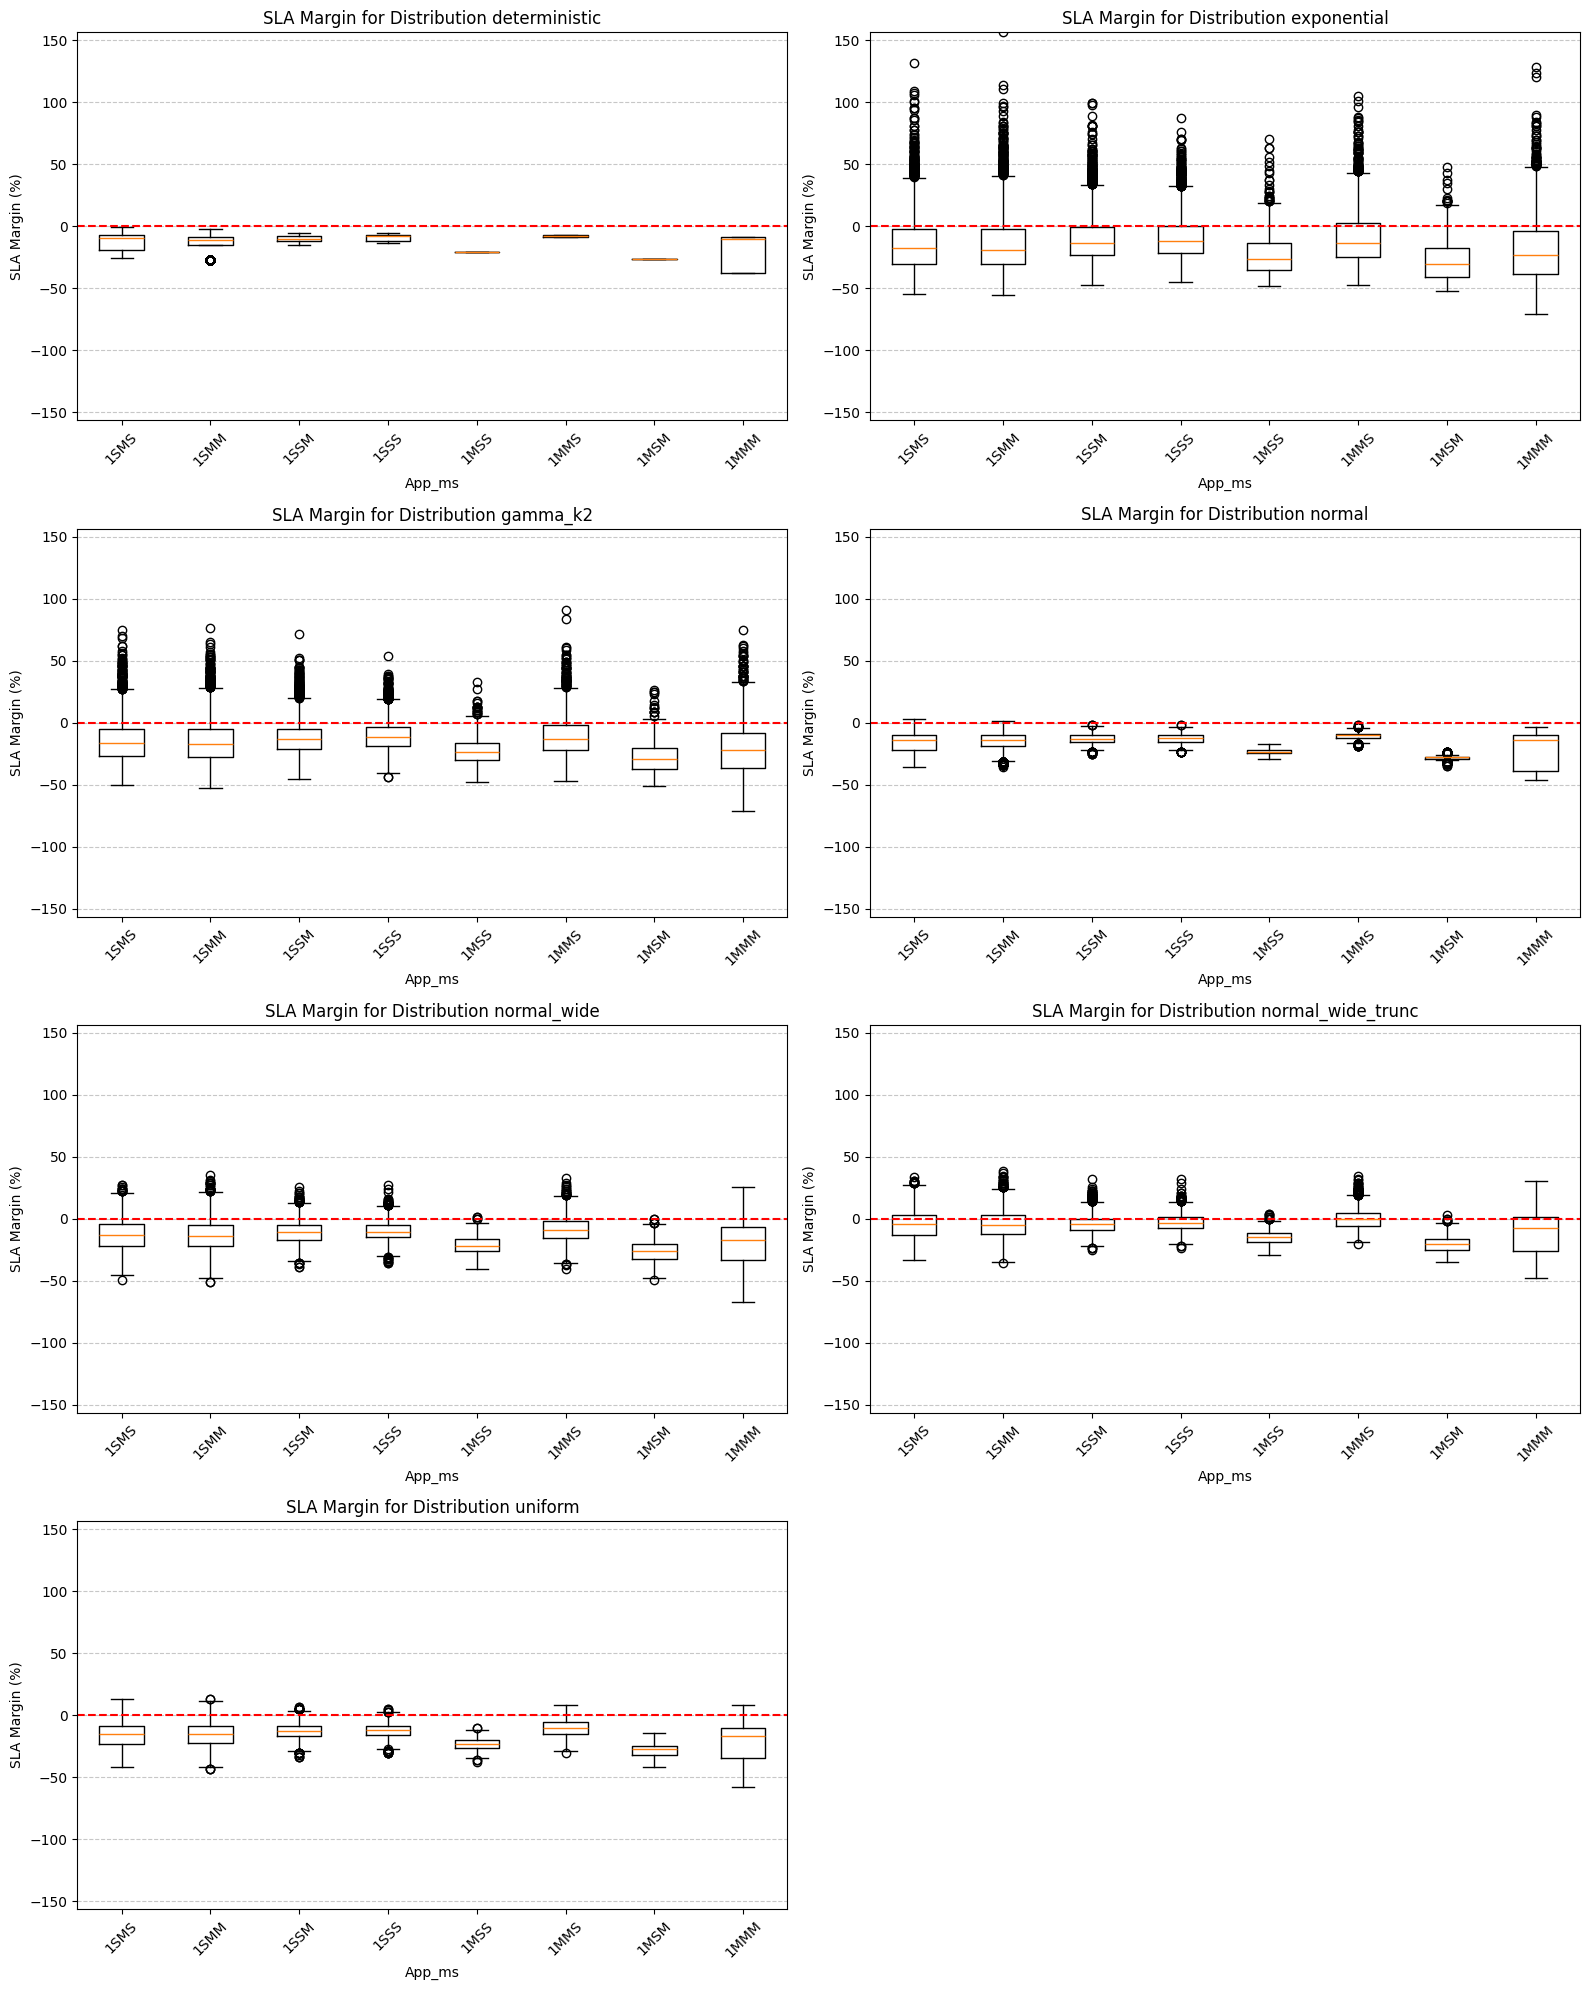

In [13]:
distributions = sorted(df['Distribution'].dropna().unique())

apps_to_plot = df['App_ms'].unique()
apps_starting_with_1 = [app for app in apps_to_plot if str(app).startswith('1')]

num_dist = len(distributions)

ncols = 2
nrows = (num_dist + 1) // 2

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(16, nrows * 5))
axes = axes.flatten()

y_min = df['SLA_Margin_Perc'].min()
y_max = df['SLA_Margin_Perc'].max()

abs_max = max(abs(y_min), abs(y_max))
y_min, y_max = -abs_max, abs_max

for i, dist in enumerate(distributions):
    ax = axes[i]
    df_dist = df[df['Distribution'] == dist]

    data = []
    labels = []

    for app in apps_starting_with_1:
        subset = df_dist.loc[df_dist['App_ms'] == app, 'SLA_Margin_Perc'].dropna()
        if len(subset) > 0:
            data.append(subset)
            labels.append(app)

    ax.boxplot(data, tick_labels=labels)#, showfliers=False)
    ax.axhline(0, linestyle='--', color='red')
    ax.set_ylim(y_min, y_max) 
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    ax.set_title(f'SLA Margin for Distribution {dist}')
    ax.set_xlabel('App_ms')
    ax.set_ylabel('SLA Margin (%)')
    ax.tick_params(axis='x', rotation=45)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

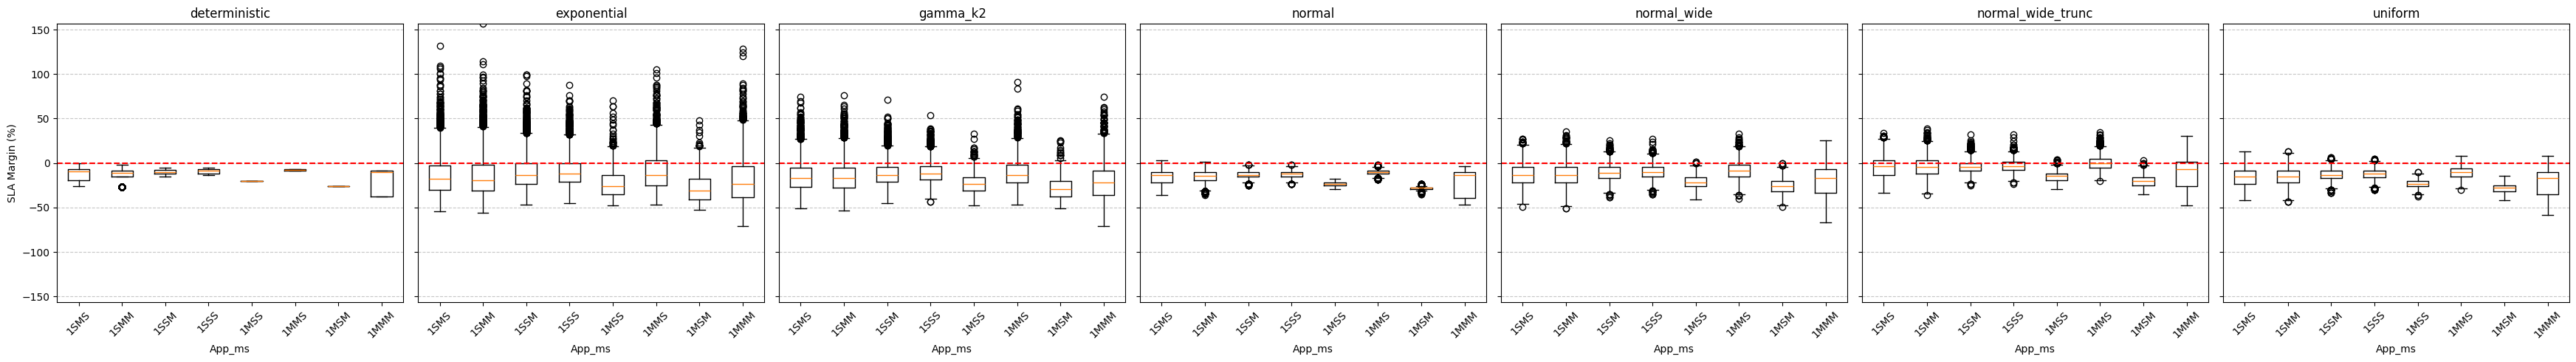

In [14]:
distributions = sorted(df['Distribution'].dropna().unique())

apps_to_plot = df['App_ms'].unique()
apps_starting_with_1 = [app for app in apps_to_plot if str(app).startswith('1')]

num_dist = len(distributions)

fig, axes = plt.subplots(1, num_dist, sharey=True, figsize=(5 * num_dist, 5))

if num_dist == 1:
    axes = [axes]

y_min = df['SLA_Margin_Perc'].min()
y_max = df['SLA_Margin_Perc'].max()

abs_max = max(abs(y_min), abs(y_max))
y_min, y_max = -abs_max, abs_max

for i, dist in enumerate(distributions):
    ax = axes[i]
    df_dist = df[df['Distribution'] == dist]

    data = []
    labels = []

    for app in apps_starting_with_1:
        subset = df_dist.loc[df_dist['App_ms'] == app, 'SLA_Margin_Perc'].dropna()
        if len(subset) > 0:
            data.append(subset)
            labels.append(app)

    ax.boxplot(data, tick_labels=labels)
    ax.axhline(0, linestyle='--', color='red')

    ax.set_ylim(y_min, y_max) 
    ax.set_title(dist)
    ax.set_xlabel('App_ms')

    if i == 0:
        ax.set_ylabel('SLA Margin (%)')

    ax.tick_params(axis='x', rotation=45)
    ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

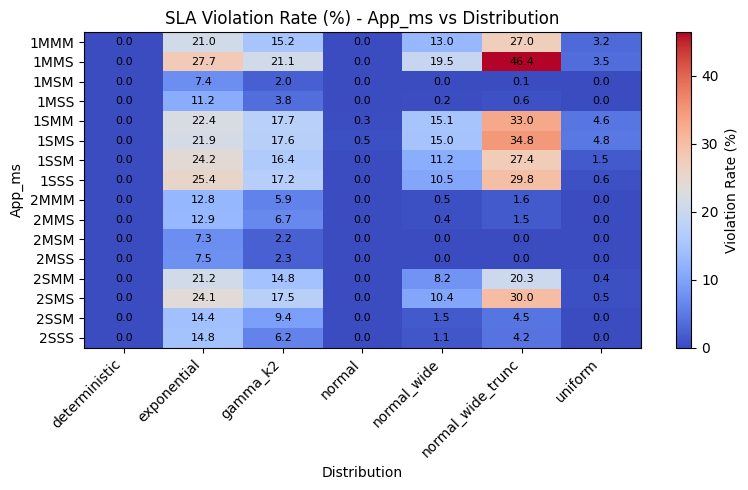

In [15]:
# percentage of run that have SLA violations

heatmap_data = (
    df.groupby(['App_ms', 'Distribution'])['SLA_Violation']
      .mean()
      .unstack() * 100
)

heatmap_data = heatmap_data.sort_index()

fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(heatmap_data.values, aspect='auto', cmap='coolwarm')

ax.set_title('SLA Violation Rate (%) - App_ms vs Distribution')
ax.set_xlabel('Distribution')
ax.set_ylabel('App_ms')

ax.set_xticks(range(len(heatmap_data.columns)))
ax.set_xticklabels(heatmap_data.columns, rotation=45, ha='right')

ax.set_yticks(range(len(heatmap_data.index)))
ax.set_yticklabels(heatmap_data.index)

for i in range(heatmap_data.shape[0]):
    for j in range(heatmap_data.shape[1]):
        value = heatmap_data.iloc[i, j]
        if pd.notna(value):
            ax.text(j, i, f"{value:.1f}", ha='center', va='center', fontsize=8)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Violation Rate (%)')

plt.tight_layout()
plt.show()

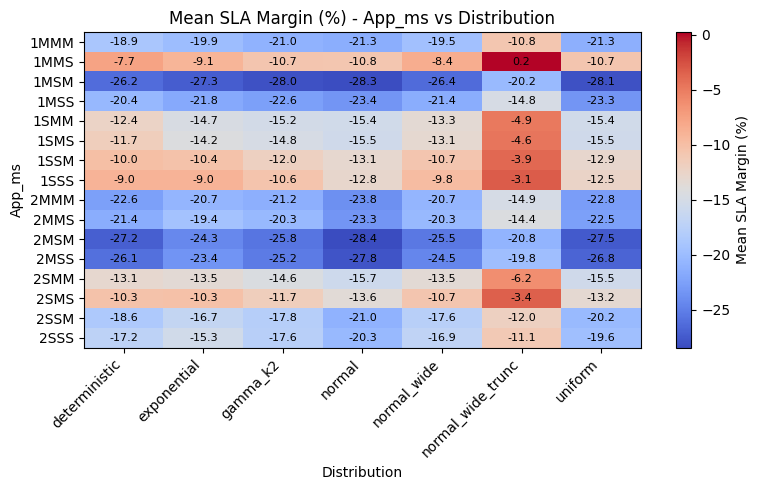

In [16]:
# mean percentage of SLA margin

heatmap_data = (
    df.groupby(['App_ms', 'Distribution'])['SLA_Margin_Perc']
      .mean()
      .unstack()
)

heatmap_data = heatmap_data.sort_index()

fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(heatmap_data.values, aspect='auto', cmap='coolwarm')

ax.set_title('Mean SLA Margin (%) - App_ms vs Distribution')
ax.set_xlabel('Distribution')
ax.set_ylabel('App_ms')

ax.set_xticks(range(len(heatmap_data.columns)))
ax.set_xticklabels(heatmap_data.columns, rotation=45, ha='right')

ax.set_yticks(range(len(heatmap_data.index)))
ax.set_yticklabels(heatmap_data.index)

for i in range(heatmap_data.shape[0]):
    for j in range(heatmap_data.shape[1]):
        value = heatmap_data.iloc[i, j]
        if pd.notna(value):
            ax.text(j, i, f"{value:.1f}", ha='center', va='center', fontsize=8)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Mean SLA Margin (%)')

plt.tight_layout()
plt.show()